# EDA — 300 International Cricket Players
**DATA-200 | Project-Stats-Team | Week 3**

Exploratory Data Analysis using descriptive statistics and visualizations to understand data patterns, relationships, and data quality.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded ')

Libraries loaded 


## 2. Load Dataset

In [2]:
df = pd.read_csv('cricket_players_300.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (300, 12)


,Player,Team,Matches,Batting_Avg,Strike_Rate,Bowling_Avg,Wickets,Fielding_Score,Experience,Performance_Score,Match_Won,Rating
0,Virat Kohli,India,40,42.45,58.42,37.57,30,61.0,4.08,43.38,0,Average
1,Rohit Sharma,India,73,32.93,63.80,20.78,81,98.8,6.87,63.28,1,Good
2,MS Dhoni,India,35,44.72,89.95,38.70,99,66.8,3.41,75.16,1,Elite
3,Sachin Tendulkar,India,51,57.85,87.21,43.56,1,59.1,5.61,52.79,0,Average
4,Sourav Ganguly,India,59,31.49,74.58,34.13,77,89.5,6.00,55.50,1,Good


## 3. Data Preprocessing

### 3.1 Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player             300 non-null    object 
 1   Team               300 non-null    object 
 2   Matches            300 non-null    int64  
 3   Batting_Avg        300 non-null    float64
 4   Strike_Rate        300 non-null    float64
 5   Bowling_Avg        300 non-null    float64
 6   Wickets            300 non-null    int64  
 7   Fielding_Score     300 non-null    float64
 8   Experience         300 non-null    float64
 9   Performance_Score  300 non-null    float64
 10  Match_Won          300 non-null    int64  
 11  Rating             300 non-null    object 
dtypes: float64(6), int64(3), object(3)
memory usage: 28.3+ KB


### 3.2 Missing Values

In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

                   Missing Count  Missing %
Player                         0        0.0
Team                           0        0.0
Matches                        0        0.0
Batting_Avg                    0        0.0
Strike_Rate                    0        0.0
Bowling_Avg                    0        0.0
Wickets                        0        0.0
Fielding_Score                 0        0.0
Experience                     0        0.0
Performance_Score              0        0.0
Match_Won                      0        0.0
Rating                         0        0.0

Total missing values: 0


### 3.3 Duplicates

In [5]:
print(f'Duplicate rows  : {df.duplicated().sum()}')
print(f'Unique players  : {df["Player"].nunique()}')

Duplicate rows  : 0
Unique players  : 300


### 3.4 Outlier Detection — IQR Method

In [6]:
num_cols = ['Batting_Avg','Strike_Rate','Bowling_Avg','Wickets','Fielding_Score','Matches','Experience','Performance_Score']

outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                            'IQR': round(IQR,2), 'Lower Fence': round(lower,2),
                            'Upper Fence': round(upper,2), 'Outliers': n_out})

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))

          Feature    Q1    Q3   IQR  Lower Fence  Upper Fence  Outliers
      Batting_Avg 24.75 44.40 19.65        -4.72        73.88         2
      Strike_Rate 60.92 87.32 26.41        21.30       126.94         1
      Bowling_Avg 24.28 37.12 12.83         5.03        56.36         0
          Wickets 26.75 87.00 60.25       -63.62       177.38         0
   Fielding_Score 62.40 86.05 23.65        26.93       121.52         0
          Matches 20.00 56.00 36.00       -34.00       110.00         0
       Experience  2.06  5.73  3.67        -3.45        11.24         0
Performance_Score 44.76 62.28 17.53        18.46        88.58         0


## 4. Descriptive Statistics

In [7]:
desc = df[num_cols].describe().T.round(3)
desc['skewness'] = df[num_cols].skew().round(3)
desc['kurtosis'] = df[num_cols].kurt().round(3)
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Batting_Avg,300.0,35.002,14.483,5.00,24.752,35.885,44.402,90.00,0.274,0.229
Strike_Rate,300.0,74.589,19.188,30.00,60.915,74.625,87.325,136.58,0.149,-0.104
Bowling_Avg,300.0,30.995,9.620,15.00,24.282,30.430,37.115,56.32,0.311,-0.428
Wickets,300.0,58.063,34.585,0.00,26.750,60.500,87.000,119.00,-0.009,-1.243
Fielding_Score,300.0,75.213,14.214,50.20,62.400,75.900,86.050,100.00,-0.018,-1.126
Matches,300.0,38.280,21.244,5.00,20.000,36.000,56.000,79.00,0.245,-1.163
Experience,300.0,3.814,2.210,-0.36,2.060,3.475,5.732,8.52,0.224,-1.097
Performance_Score,300.0,54.003,12.391,19.10,44.755,54.765,62.285,82.31,-0.100,-0.396


### Categorical Summary

In [8]:
print('Team Distribution:')
print(df['Team'].value_counts().to_string())
print('\nRating Distribution:')
print(df['Rating'].value_counts().to_string())
print(f'\nWin Rate: {df["Match_Won"].mean():.1%}')

Team Distribution:
Team
India           60
Australia       60
England         60
South Africa    60
New Zealand     60

Rating Distribution:
Rating
Good             122
Average          107
Below Average     45
Elite             26

Win Rate: 49.3%


## 5. Visualizations

### 5.1 Histograms — Distribution of All Numeric Features

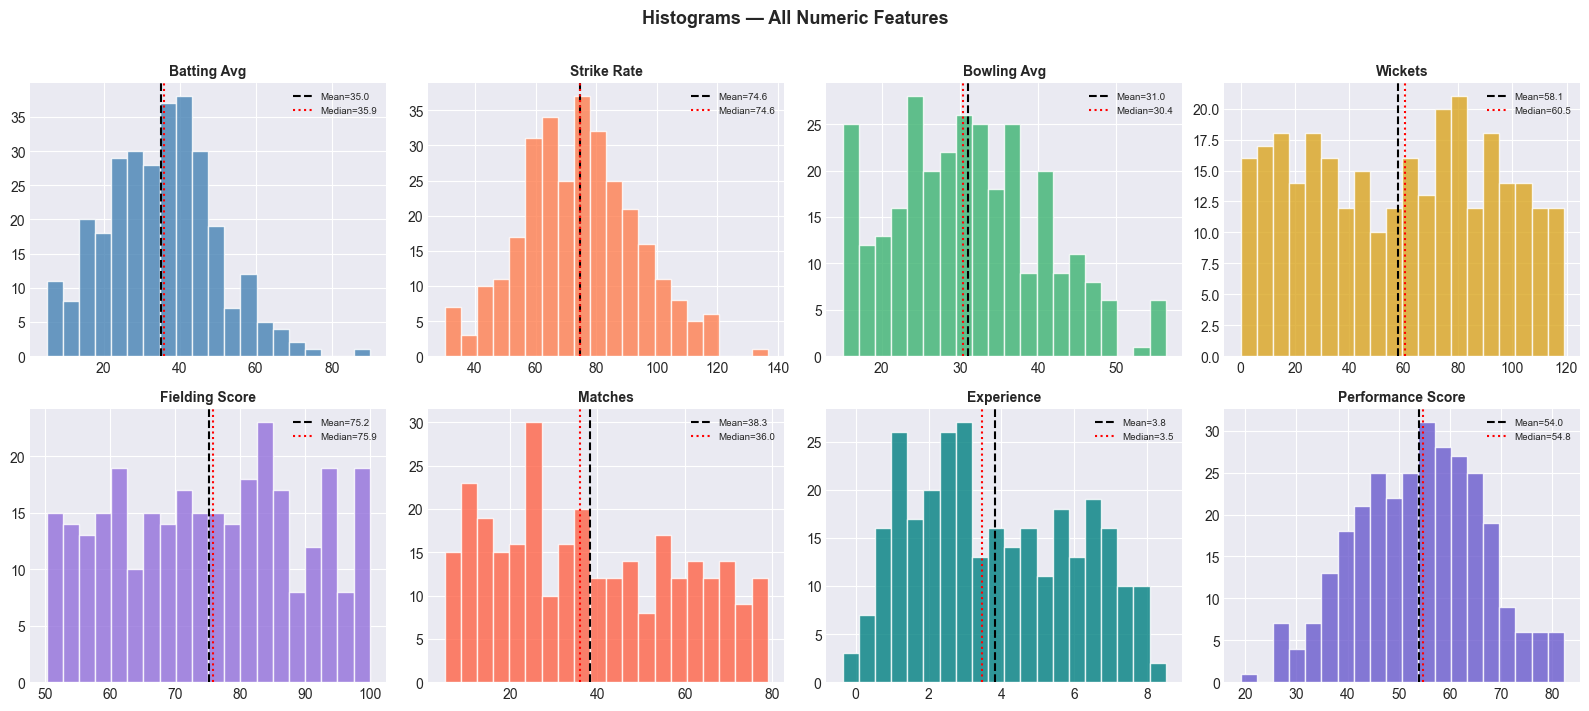

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ['steelblue','coral','mediumseagreen','goldenrod','mediumpurple','tomato','teal','slateblue']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(),   color='black', linestyle='--', lw=1.5, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='red',   linestyle=':',  lw=1.5, label=f'Median={df[col].median():.1f}')
    axes[i].set_title(col.replace('_',' '), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

fig.suptitle('Histograms — All Numeric Features', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### 5.2 Box Plots — Outlier Detection

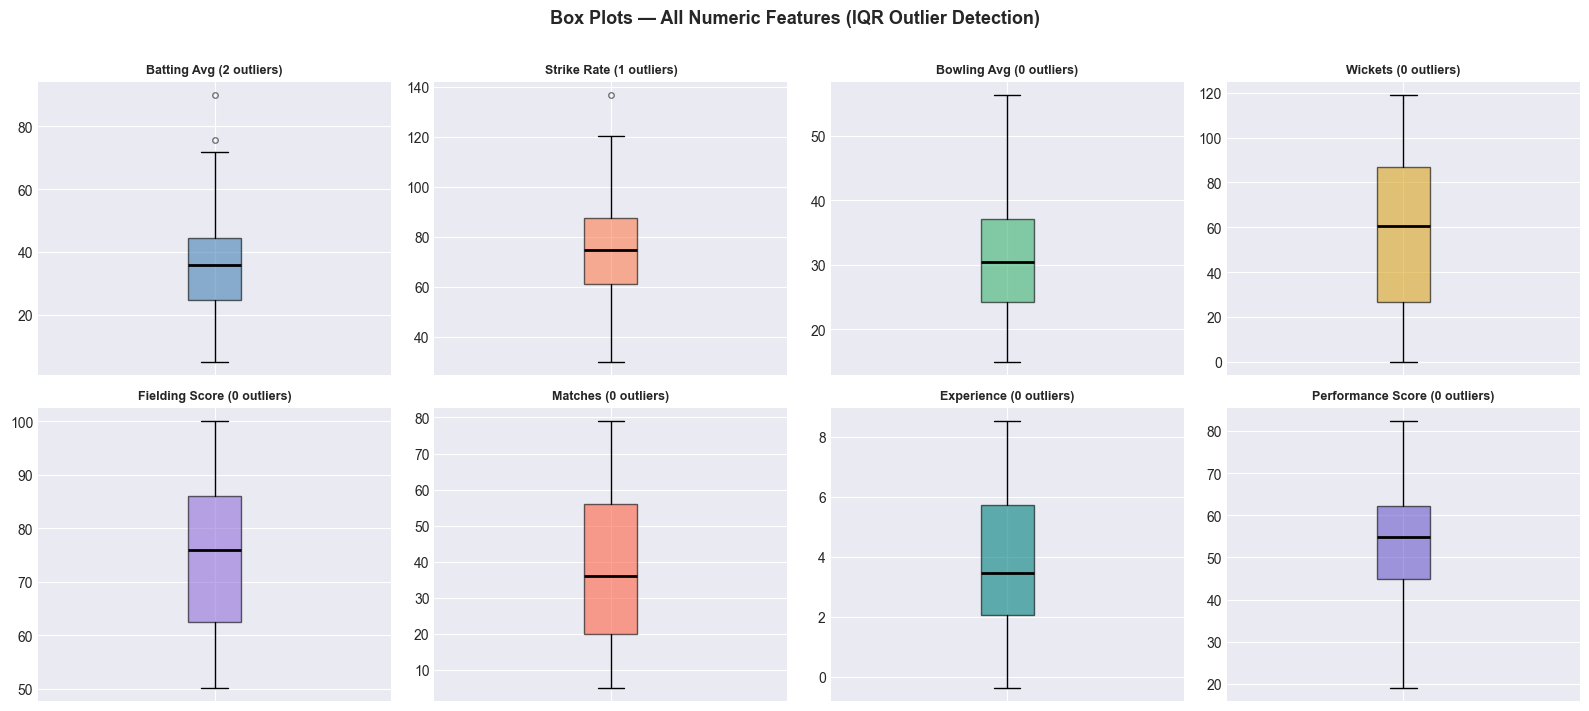

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.6),
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', color='red', alpha=0.5, markersize=4))
    n_out = out_df[out_df['Feature']==col]['Outliers'].values[0]
    axes[i].set_title(f'{col.replace("_"," ")} ({n_out} outliers)', fontsize=9, fontweight='bold')
    axes[i].set_xticklabels([])

fig.suptitle('Box Plots — All Numeric Features (IQR Outlier Detection)', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

### 5.3 Scatter Plots — Key Relationships with Performance Score

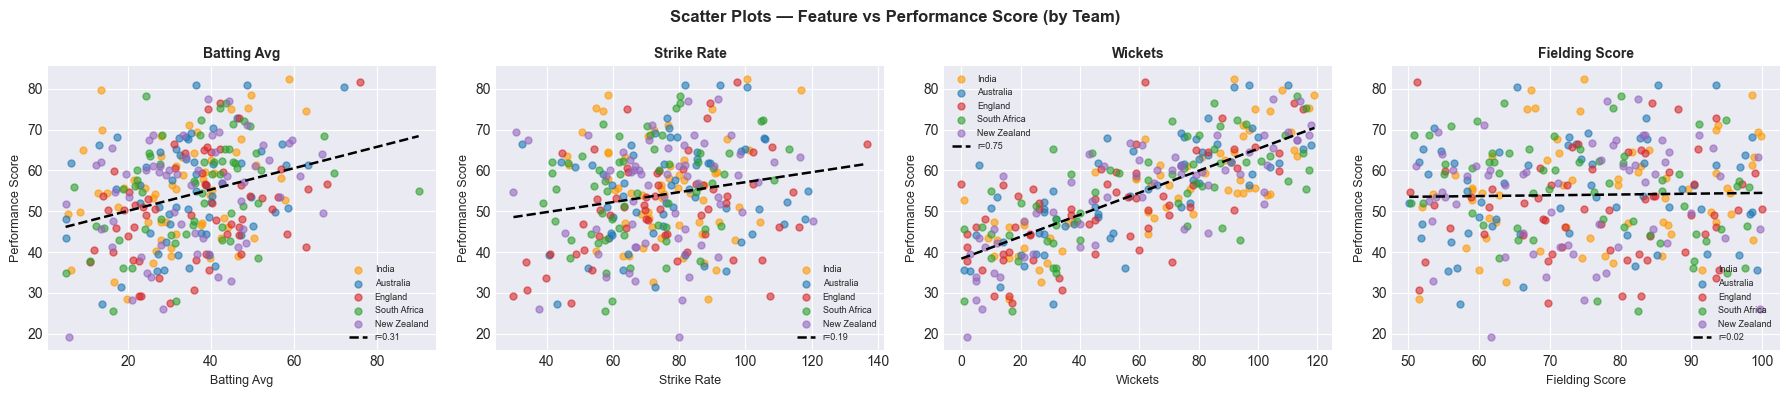

In [11]:
feature_cols = ['Batting_Avg', 'Strike_Rate', 'Wickets', 'Fielding_Score']
team_colors  = {'India':'#ff9900','Australia':'#1f77b4','England':'#d62728','South Africa':'#2ca02c','New Zealand':'#9467bd'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, feature_cols):
    for team, tc in team_colors.items():
        sub = df[df['Team']==team]
        ax.scatter(sub[col], sub['Performance_Score'], color=tc, alpha=0.6, s=25, label=team)
    m, b, r, p, _ = stats.linregress(df[col], df['Performance_Score'])
    xl = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xl, m*xl+b, color='black', lw=1.8, linestyle='--', label=f'r={r:.2f}')
    ax.set_xlabel(col.replace('_',' '), fontsize=9)
    ax.set_ylabel('Performance Score', fontsize=9)
    ax.set_title(col.replace('_',' '), fontsize=10, fontweight='bold')
    ax.legend(fontsize=6.5)

fig.suptitle('Scatter Plots — Feature vs Performance Score (by Team)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

### 5.4 Correlation Heatmap

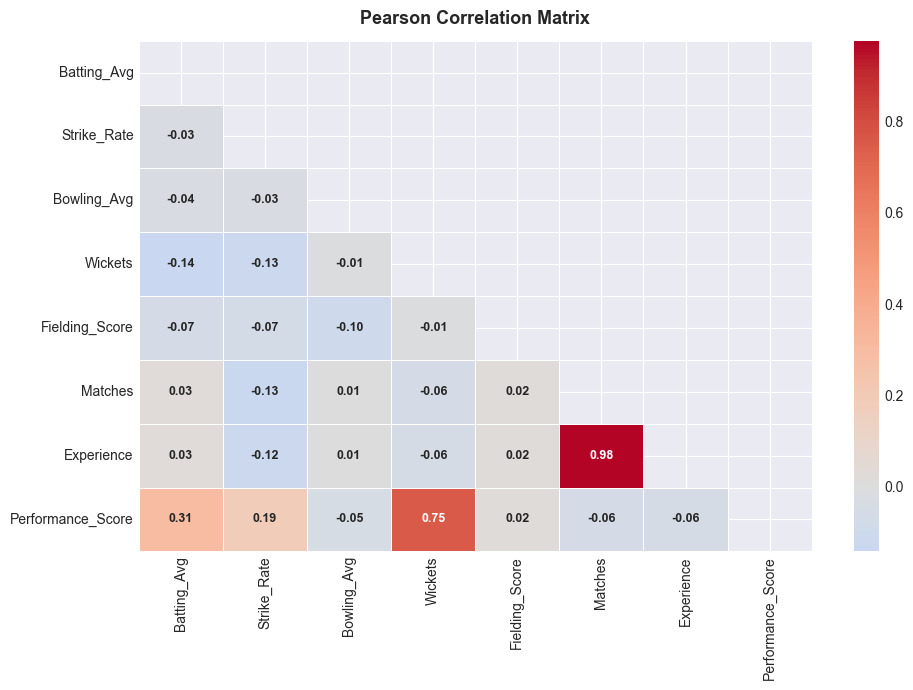

In [12]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size':9, 'weight':'bold'}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()

### 5.5 Performance Score by Team

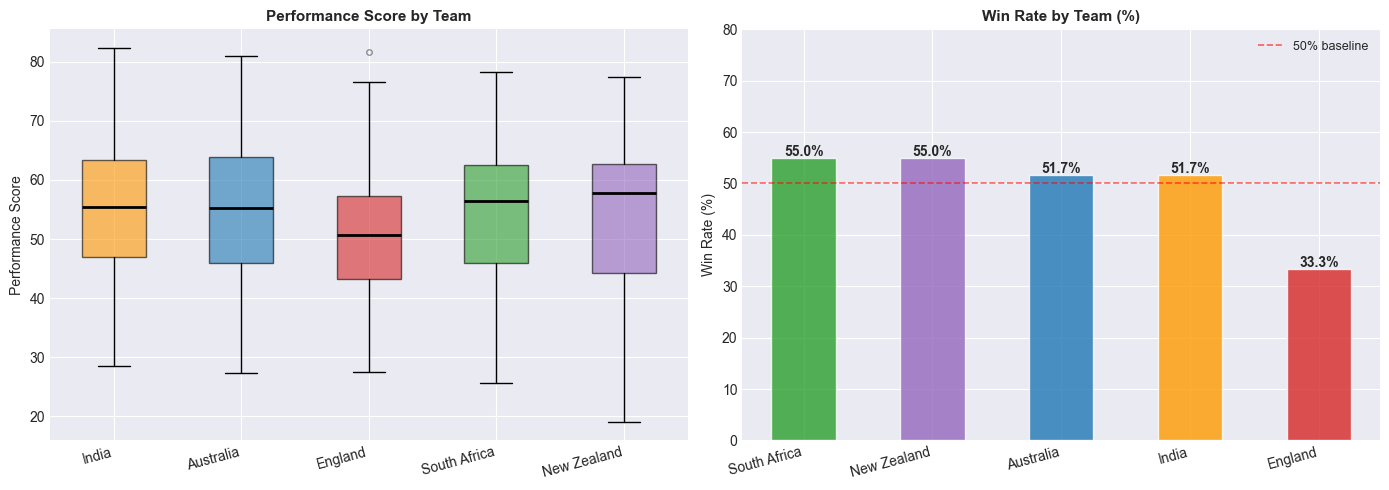

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box by team
teams = df['Team'].unique()
bdata = [df[df['Team']==t]['Performance_Score'].values for t in teams]
bp = axes[0].boxplot(bdata, labels=teams, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
tc_list = [list(team_colors.values())[i] for i in range(len(teams))]
for patch, col in zip(bp['boxes'], tc_list): patch.set_facecolor(col); patch.set_alpha(0.6)
axes[0].set_title('Performance Score by Team', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Performance Score')
axes[0].set_xticklabels(teams, rotation=15, ha='right')

# Win rate bar
wr = df.groupby('Team')['Match_Won'].mean().sort_values(ascending=False)
bars = axes[1].bar(wr.index, wr.values*100, color=[team_colors[t] for t in wr.index], alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, wr.values*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(50, color='red', linestyle='--', lw=1.2, alpha=0.6, label='50% baseline')
axes[1].set_title('Win Rate by Team (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)'); axes[1].set_ylim(0, 80)
axes[1].set_xticklabels(wr.index, rotation=15, ha='right')
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

### 5.6 Rating Distribution

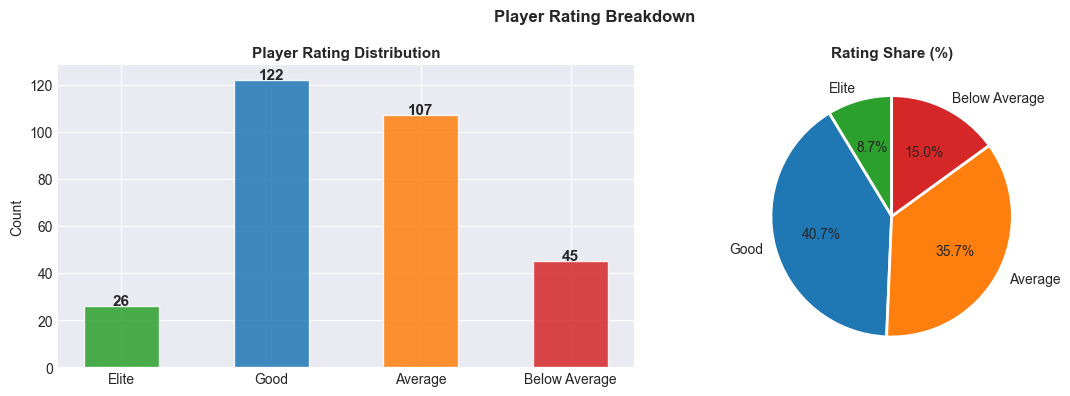

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
rating_order = ['Elite','Good','Average','Below Average']
rating_c = df['Rating'].value_counts().reindex(rating_order)
bar_colors = ['#2ca02c','#1f77b4','#ff7f0e','#d62728']
bars = axes[0].bar(rating_c.index, rating_c.values, color=bar_colors, edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, rating_c.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, str(val),
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Player Rating Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie
axes[1].pie(rating_c.values, labels=rating_c.index, colors=bar_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Rating Share (%)', fontsize=11, fontweight='bold')

fig.suptitle('Player Rating Breakdown', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. EDA Summary & Key Insights

| Finding | Detail |
|---------|--------|
| **Missing Values** | No missing values found — dataset is clean |
| **Duplicates** | No duplicate rows detected |
| **Outliers** | Very few outliers across features (IQR method) |
| **Performance Score** | Approx. normally distributed (mean ≈ 55, slight skew) |
| **Top Correlates** | Wickets & Batting Avg most strongly correlated with Performance Score |
| **Team Balance** | Each team has exactly 60 players — perfectly balanced |
| **Win Rate** | ~56% overall win rate — slightly imbalanced |
| **Elite Players** | ~27% rated Elite (Performance Score > 70) |

> **Next Step ** Apply t-Test, ANOVA, Linear Regression, and Logistic Regression based on these findings.
